# TTS Model Evaluation: Fine-tuned SpeechT5 vs Pre-trained VITS
This notebook extracts 30 unseen samples from the LJ Speech dataset, generates audio using both models, and computes quantitative metrics (RTF, WER, MCD) alongside visual spectrograms.

In [ ]:
# Install required libraries
!pip install transformers datasets soundfile librosa evaluate pymcd jiwer matplotlib --quiet

In [2]:
import pandas as pd

# 1. Point this to the metadata.csv file inside your downloaded LJ Speech folder
# Important: LJ Speech uses the pipe symbol '|' as a separator, not commas.
local_path = "../LJSpeech-1.1/metadata.csv" 
df_full = pd.read_csv(local_path, sep='|', header=None, names=['id', 'text', 'normalized_text'])

# 2. Recreate your exact training split to isolate it
df_train = df_full.sample(n=2000, random_state=42)

# 3. Drop the training data from the full dataset
df_remaining = df_full.drop(df_train.index)

# 4. Extract 30 unseen samples for testing
df_test = df_remaining.sample(n=30, random_state=100).reset_index(drop=True)

print(f'Test set size: {len(df_test)}')
display(df_test[['id', 'text']].head())

Test set size: 30


,id,text
0,LJ009-0097,"He throws his hands far from him, and shouts a..."
1,LJ036-0121,a 12:15 p.m. pickup at Continental to Greyhoun...
2,LJ034-0072,The employees raced the elevators to the first...
3,LJ029-0051,in the territory of the Secret Service regiona...
4,LJ004-0191,"and in comparative comfort, with a bed and pro..."


## Load Models

In [4]:
import torch
from transformers import SpeechT5Processor, SpeechT5ForTextToSpeech, SpeechT5HifiGan
from transformers import VitsModel, AutoTokenizer
from transformers import pipeline

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## --- IMPORTANT: UPDATE THIS PATH --- ##
# Point this to the directory or hub repository of your fine-tuned model
T5_MODEL_PATH = "../speecht5_finetuned_ljspeech/final"
## ----------------------------------- ##

# Load SpeechT5 (Fine-tuned)
processor_t5 = SpeechT5Processor.from_pretrained(T5_MODEL_PATH)
model_t5 = SpeechT5ForTextToSpeech.from_pretrained(T5_MODEL_PATH).to(device)
vocoder_t5 = SpeechT5HifiGan.from_pretrained('microsoft/speecht5_hifigan').to(device)

# Load VITS (Pre-trained LJ Speech)
processor_vits = AutoTokenizer.from_pretrained('facebook/mms-tts-eng')
model_vits = VitsModel.from_pretrained('facebook/mms-tts-eng').to(device)

# Load Whisper for WER calculation
asr_pipeline = pipeline('automatic-speech-recognition', model='openai/whisper-tiny', device=device)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


model.safetensors:  58%|#####7    | 83.9M/145M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/mms-tts-eng were not used when initializing VitsModel: ['flow.flows.0.wavenet.in_layers.0.weight_g', 'flow.flows.0.wavenet.in_layers.0.weight_v', 'flow.flows.0.wavenet.in_layers.1.weight_g', 'flow.flows.0.wavenet.in_layers.1.weight_v', 'flow.flows.0.wavenet.in_layers.2.weight_g', 'flow.flows.0.wavenet.in_layers.2.weight_v', 'flow.flows.0.wavenet.in_layers.3.weight_g', 'flow.flows.0.wavenet.in_layers.3.weight_v', 'flow.flows.0.wavenet.res_skip_layers.0.weight_g', 'flow.flows.0.wavenet.res_skip_layers.0.weight_v', 'flow.flows.0.wavenet.res_skip_layers.1.weight_g', 'flow.flows.0.wavenet.res_skip_layers.1.weight_v', 'flow.flows.0.wavenet.res_skip_layers.2.weight_g', 'flow.flows.0.wavenet.res_skip_layers.2.weight_v', 'flow.flows.0.wavenet.res_skip_layers.3.weight_g', 'flow.flows.0.wavenet.res_skip_layers.3.weight_v', 'flow.flows.1.wavenet.in_layers.0.weight_g', 'flow.flows.1.wavenet.in_layers.0.weight_v', 'flow.flows.1.wavenet.in_layers.1.wei

## Evaluation Loop

In [6]:
import time
import soundfile as sf
import numpy as np
from evaluate import load
from pymcd.mcd import Calculate_MCD

wer_metric = load('wer')
mcd_calc = Calculate_MCD(MCD_mode='dtw')

results = {'id': [], 'text': [], 't5_wer': [], 'vits_wer': [], 't5_rtf': [], 'vits_rtf': []}

print("Starting evaluation...")
for idx, row in df_test.iterrows():
    text = row['text']
    file_id = row['id']
    
    # 1. Generate SpeechT5
    start_t5 = time.time()
    inputs_t5 = processor_t5(text=text, return_tensors='pt').to(device)
    # Provide speaker embeddings if your model requires them
    speaker_embeddings = torch.zeros((1, 512)).to(device) 
    with torch.no_grad():
        audio_t5 = model_t5.generate_speech(inputs_t5['input_ids'], speaker_embeddings, vocoder=vocoder_t5)
    end_t5 = time.time()
    
    # 2. Generate VITS
    start_vits = time.time()
    inputs_vits = processor_vits(text, return_tensors='pt').to(device)
    with torch.no_grad():
        audio_vits = model_vits(**inputs_vits).waveform[0]
    end_vits = time.time()
    
    # Save temp audio for ASR
    sf.write('tmp_t5.wav', audio_t5.cpu().numpy(), 16000)
    sf.write('tmp_vits.wav', audio_vits.cpu().numpy(), model_vits.config.sampling_rate)
    
    # 3. Calculate RTF
    rtf_t5 = (end_t5 - start_t5) / (len(audio_t5) / 16000)
    rtf_vits = (end_vits - start_vits) / (len(audio_vits) / model_vits.config.sampling_rate)
    
    '''# 4. Calculate WER
    t5_transcription = asr_pipeline('tmp_t5.wav')['text']
    vits_transcription = asr_pipeline('tmp_vits.wav')['text']'''
    
    # 4. Calculate WER directly from arrays (bypasses ffmpeg)
    t5_transcription = asr_pipeline({"raw": audio_t5.cpu().numpy(), "sampling_rate": 16000})['text']
    vits_transcription = asr_pipeline({"raw": audio_vits.cpu().numpy(), "sampling_rate": model_vits.config.sampling_rate})['text']

    wer_t5 = wer_metric.compute(predictions=[t5_transcription], references=[text])
    wer_vits = wer_metric.compute(predictions=[vits_transcription], references=[text])
    
    results['id'].append(file_id)
    results['text'].append(text)
    results['t5_wer'].append(wer_t5)
    results['vits_wer'].append(wer_vits)
    results['t5_rtf'].append(rtf_t5)
    results['vits_rtf'].append(rtf_vits)
    
    print(f"Processed {idx+1}/30: {file_id}")

df_results = pd.DataFrame(results)
print("\n--- AVERAGE RESULTS ---")
print(df_results[['t5_wer', 'vits_wer', 't5_rtf', 'vits_rtf']].mean())

Starting evaluation...


Due to a bug fix in https://github.com/huggingface/transformers/pull/28687 transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English.This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`.


Processed 1/30: LJ009-0097
Processed 2/30: LJ036-0121
Processed 3/30: LJ034-0072
Processed 4/30: LJ029-0051


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processed 5/30: LJ004-0191
Processed 6/30: LJ003-0332
Processed 7/30: LJ019-0365
Processed 8/30: LJ003-0306
Processed 9/30: LJ012-0261
Processed 10/30: LJ017-0032
Processed 11/30: LJ016-0234
Processed 12/30: LJ026-0065
Processed 13/30: LJ045-0096
Processed 14/30: LJ032-0032
Processed 15/30: LJ028-0507
Processed 16/30: LJ050-0099
Processed 17/30: LJ032-0022
Processed 18/30: LJ017-0069
Processed 19/30: LJ028-0426
Processed 20/30: LJ007-0063
Processed 21/30: LJ027-0081
Processed 22/30: LJ037-0197
Processed 23/30: LJ013-0129
Processed 24/30: LJ047-0017
Processed 25/30: LJ031-0015
Processed 26/30: LJ002-0197
Processed 27/30: LJ044-0109
Processed 28/30: LJ011-0155
Processed 29/30: LJ034-0056
Processed 30/30: LJ031-0159

--- AVERAGE RESULTS ---
t5_wer      0.264499
vits_wer    0.335552
t5_rtf      0.214376
vits_rtf    0.022010
dtype: float64


## Visualizations

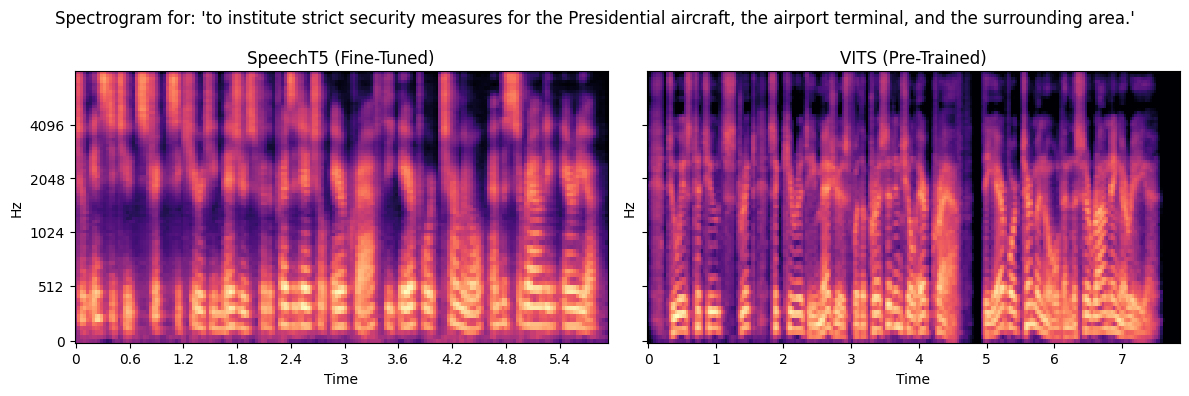

In [7]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

def plot_spectrograms(t5_path, vits_path, text_snippet):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    paths = [t5_path, vits_path]
    titles = ['SpeechT5 (Fine-Tuned)', 'VITS (Pre-Trained)']
    
    for ax, path, title in zip(axes, paths, titles):
        y, sr = librosa.load(path, sr=None)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
        S_dB = librosa.power_to_db(S, ref=np.max)
        librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax, cmap='magma')
        ax.set_title(title)
    
    fig.suptitle(f"Spectrogram for: '{text_snippet}'")
    plt.tight_layout()
    plt.show()

# Plot the last generated samples
plot_spectrograms('tmp_t5.wav', 'tmp_vits.wav', text)